# NB17 — Linear Probing: Task Identity vs Refusal Behaviour

**Core question:** Does task identity become decodable from residual-stream representations *earlier* in the forward pass than refusal behaviour?

**Intuition (from the paper's two-subspace account):**
- Arditi's direction converges by **L3** — before task constellations form.
- Task-identity constellations peak at **L12**.
- Over-refusal is a within-task perturbation that emerges *after* task structure is established.

If this story is correct, a linear probe trained to decode task identity should become accurate several layers *before* a probe trained to decode refusal behaviour. This temporal gap is the **functional** complement to the representational (PCA) evidence in NB16.

**Three probes:**
1. **Task probe** — 5-class logistic regression on all 270 samples: which task?
2. **Refusal-behaviour probe** — binary logistic on benign-task samples only: OR vs TARGET
3. **Refusal-type probe** — binary logistic on refused samples only: OR vs REFUSED\_HARMFUL
   (can representations tell apart *erroneous* refusal from *legitimate* refusal?)

**Metric:** Balanced accuracy (accounts for class imbalance) via 5-fold stratified cross-validation.

**No GPU required.**

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import json
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import balanced_accuracy_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# ── Publication-ready style (ACL two-column format) ────────────────────────────
plt.rcParams.update({
    'font.size':         13,
    'font.family':       'serif',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   12,
    'legend.frameon':    True,
    'legend.edgecolor':  '0.8',
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.6,
    'axes.linewidth':    1.1,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'lines.linewidth':   2.2,
    'patch.linewidth':   1.0,
})

PAL = {
    'task':       '#2C3E50',   # dark navy  — task probe
    'refusal':    '#E74C3C',   # red        — refusal-behaviour probe
    'type':       '#8E44AD',   # purple     — refusal-type probe
    'arditi':     '#2C3E50',
    'or_global':  '#E74C3C',
    'ref_line':   '#7F8C8D',
    'chance':     '#BDC3C7',
}
TASK_NAMES = ['cryptanalysis', 'rag_qa', 'rephrase', 'sentiment_analysis', 'translate']

print('Libraries and style loaded.')

Libraries and style loaded.


In [2]:
from google.colab import drive; drive.mount('/content/drive')
import os
os.makedirs('./embeddings', exist_ok=True)
os.makedirs('./arditi_artefacts', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/* arditi_artefacts/

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


In [3]:
# ── Load embeddings (identical pattern to NB16) ────────────────────────────────
def to_numpy(emb_dict):
    out = {}
    for k, v in emb_dict.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.float().numpy().astype(np.float32)
        else:
            out[k] = np.array([e.float().numpy().astype(np.float32) for e in v])
    return out

embeddings_dir = './embeddings/'
csv_path = os.path.join(embeddings_dir,
    sorted(f for f in os.listdir(embeddings_dir) if f.endswith('.csv'))[-1])
csv_df = pd.read_csv(csv_path)

torch_data           = torch.load(csv_df['torch_path'].iloc[0])
embeddings_np        = to_numpy(torch_data['embeddings'])
texts                = torch_data['texts']
responses            = torch_data['responses']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

LAYER_NAMES = [f'layer_{l}_input_norm' for l in range(32)
               if f'layer_{l}_input_norm' in embeddings_np]
LAYER_NUMS  = [int(ln.replace('layer_','').replace('_input_norm',''))
               for ln in LAYER_NAMES]

print(f'{len(texts)} samples | {len(LAYER_NAMES)} layers | dim={list(embeddings_np.values())[0].shape[1]}')

270 samples | 31 layers | dim=4096


In [4]:
# ── Behavioural group masks (consistent with NB7 / NB14 / NB16) ───────────────
REFUSING_MASK = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
ANSWERED_MASK = refusal_labels == 'direct_answer'
HARMFUL_MASK  = text_type_labels == 'harmful_instruction'

BENIGN_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
BENIGN_MASK  = np.isin(intended_task_labels, BENIGN_TASKS)

TARGET_MASK       = ((response_labels == 'cautious') | (response_labels == 'not_harmful')) & ANSWERED_MASK
OVER_REFUSAL_MASK = BENIGN_MASK & REFUSING_MASK
REFUSED_HARMFUL   = HARMFUL_MASK & REFUSING_MASK
HARMLESS_ANSWERED = BENIGN_MASK  & ANSWERED_MASK

print('=== SAMPLE COUNTS ===')
print(f'  Over-refusal (benign refused):      {OVER_REFUSAL_MASK.sum():>4d}')
print(f'  Target (benign answered):           {TARGET_MASK.sum():>4d}')
print(f'  Refused-harmful (Arditi class A):   {REFUSED_HARMFUL.sum():>4d}')
print(f'  Harmless-answered (Arditi class B): {HARMLESS_ANSWERED.sum():>4d}')
print()
print('--- Probe sample sizes ---')
print(f'  Task probe          : n={len(texts)} (5 classes)')
print(f'  Refusal-behav probe : n={OVER_REFUSAL_MASK.sum() + TARGET_MASK.sum()}  (OR={OVER_REFUSAL_MASK.sum()} vs TARGET={TARGET_MASK.sum()})')
print(f'  Refusal-type probe  : n={OVER_REFUSAL_MASK.sum() + REFUSED_HARMFUL.sum()}  (OR={OVER_REFUSAL_MASK.sum()} vs HARM={REFUSED_HARMFUL.sum()})')

=== SAMPLE COUNTS ===
  Over-refusal (benign refused):        48
  Target (benign answered):            169
  Refused-harmful (Arditi class A):     25
  Harmless-answered (Arditi class B):  157

--- Probe sample sizes ---
  Task probe          : n=270 (5 classes)
  Refusal-behav probe : n=217  (OR=48 vs TARGET=169)
  Refusal-type probe  : n=73  (OR=48 vs HARM=25)


In [5]:
# ── Load Arditi best layer from NB8 metadata ──────────────────────────────────
with open('arditi_artefacts/direction_metadata.json') as f:
    nb8_meta = json.load(f)
BEST_LAYER = nb8_meta['best_layer']   # 'layer_12_input_norm'
BEST_LNUM  = int(BEST_LAYER.replace('layer_','').replace('_input_norm',''))
print(f'Arditi best layer: {BEST_LAYER}  (L{BEST_LNUM})')

# Reference verticals for all figures
ARDITI_LAYER = 3    # convergence layer (from NB9: 89% cross-task alignment by L3)
CONST_PEAK   = 12   # constellation peak (from NB13a)

Arditi best layer: layer_12_input_norm  (L12)


In [6]:
# ── Probe helper ───────────────────────────────────────────────────────────────
# We use a simple L2-regularised logistic regression inside a StandardScaler pipeline.
# Metric: balanced accuracy (handles class imbalance in refusal-behaviour and refusal-type probes).
# CV: StratifiedKFold(5) to preserve class ratios in each fold.

BAL_ACC = make_scorer(balanced_accuracy_score)
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def probe_layer(X, y, cv=CV, scorer=BAL_ACC):
    """
    Fit a logistic-regression probe on (X, y) with 5-fold stratified CV.
    Returns mean and std of balanced accuracy across folds.
    X : (n_samples, d_model)  raw embeddings at one layer
    y : (n_samples,)          integer labels
    """
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, C=1.0,
                                      class_weight='balanced',
                                      solver='lbfgs', random_state=42,
                                      multi_class='auto'))
    ])
    res = cross_validate(pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    return res['test_score'].mean(), res['test_score'].std()

print('Probe helper defined.')
print('  Metric : balanced accuracy (5-fold stratified CV)')
print('  Chance : 1/n_classes  (20% for task, 50% for binary)')

Probe helper defined.
  Metric : balanced accuracy (5-fold stratified CV)
  Chance : 1/n_classes  (20% for task, 50% for binary)


In [7]:
# ── Run all three probes at every layer ───────────────────────────────────────
# This cell is the expensive one (~1-2 min on Colab CPU for 31 layers).

# Encode task labels as integers
all_tasks_sorted = sorted(set(intended_task_labels))
task_to_int = {t: i for i, t in enumerate(all_tasks_sorted)}
y_task = np.array([task_to_int[t] for t in intended_task_labels])   # all 270

# Refusal-behaviour probe: OR=1 vs TARGET=0  (within benign-task samples)
BEHAV_MASK = OVER_REFUSAL_MASK | TARGET_MASK
y_behav    = OVER_REFUSAL_MASK[BEHAV_MASK].astype(int)              # 1=OR, 0=TARGET

# Refusal-type probe: OR=1 vs REFUSED_HARMFUL=0  (both refused, different cause)
TYPE_MASK  = OVER_REFUSAL_MASK | REFUSED_HARMFUL
y_type     = OVER_REFUSAL_MASK[TYPE_MASK].astype(int)               # 1=OR, 0=harm

results = []
for lname, lnum in zip(LAYER_NAMES, LAYER_NUMS):
    emb = embeddings_np[lname]                 # (270, 4096)

    mu_task,   sd_task   = probe_layer(emb,              y_task)
    mu_behav,  sd_behav  = probe_layer(emb[BEHAV_MASK],  y_behav)
    mu_type,   sd_type   = probe_layer(emb[TYPE_MASK],   y_type)

    results.append(dict(
        layer    = lnum,
        task_mu  = mu_task,   task_sd  = sd_task,
        behav_mu = mu_behav,  behav_sd = sd_behav,
        type_mu  = mu_type,   type_sd  = sd_type,
    ))
    print(f'  L{lnum:02d}  task={mu_task:.3f}±{sd_task:.3f}  '
          f'behav={mu_behav:.3f}±{sd_behav:.3f}  '
          f'type={mu_type:.3f}±{sd_type:.3f}')

df = pd.DataFrame(results)
print('\nAll probes done.')

  L00  task=0.200±0.000  behav=0.500±0.000  type=0.500±0.000
  L01  task=0.970±0.021  behav=0.860±0.064  type=1.000±0.000
  L02  task=0.946±0.025  behav=0.849±0.053  type=1.000±0.000
  L03  task=0.966±0.019  behav=0.861±0.071  type=1.000±0.000
  L04  task=0.983±0.019  behav=0.892±0.060  type=1.000±0.000
  L05  task=0.973±0.014  behav=0.879±0.051  type=1.000±0.000
  L06  task=0.996±0.007  behav=0.869±0.052  type=1.000±0.000
  L07  task=0.990±0.013  behav=0.882±0.042  type=1.000±0.000
  L08  task=0.977±0.009  behav=0.859±0.034  type=1.000±0.000
  L09  task=0.973±0.017  behav=0.888±0.064  type=1.000±0.000
  L10  task=0.969±0.022  behav=0.872±0.045  type=1.000±0.000
  L11  task=0.970±0.019  behav=0.874±0.049  type=1.000±0.000
  L12  task=0.976±0.018  behav=0.905±0.020  type=1.000±0.000
  L13  task=0.979±0.020  behav=0.919±0.053  type=1.000±0.000
  L14  task=0.969±0.020  behav=0.936±0.044  type=1.000±0.000
  L15  task=0.967±0.023  behav=0.936±0.043  type=1.000±0.000
  L16  task=0.960±0.025 

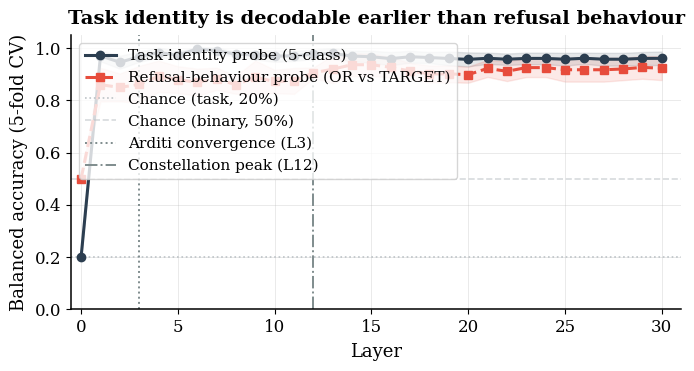

Fig 1 saved.


In [8]:
# ── Figure 1: Task probe vs Refusal-behaviour probe ───────────────────────────
# Core paper figure — shows the temporal gap between task encoding and refusal encoding.
# ACL single-column width: figsize=(3.5, 3.5); two-column width: figsize=(7, 3.8)

layers = df['layer'].values

fig, ax = plt.subplots(figsize=(7, 3.8))

# Task probe
ax.plot(layers, df['task_mu'],  'o-',  color=PAL['task'],    lw=2.2, zorder=3,
        label='Task-identity probe (5-class)')
ax.fill_between(layers,
                df['task_mu'] - df['task_sd'],
                df['task_mu'] + df['task_sd'],
                color=PAL['task'], alpha=0.12)

# Refusal-behaviour probe
ax.plot(layers, df['behav_mu'], 's--', color=PAL['refusal'], lw=2.2, zorder=3,
        label='Refusal-behaviour probe (OR vs TARGET)')
ax.fill_between(layers,
                df['behav_mu'] - df['behav_sd'],
                df['behav_mu'] + df['behav_sd'],
                color=PAL['refusal'], alpha=0.12)

# Reference lines
ax.axhline(1/5, color=PAL['chance'], lw=1.2, ls=':', label='Chance (task, 20%)')
ax.axhline(0.5, color=PAL['chance'], lw=1.2, ls='--', label='Chance (binary, 50%)', alpha=0.6)
ax.axvline(ARDITI_LAYER, color=PAL['ref_line'], lw=1.4, ls=':',
           label=f'Arditi convergence (L{ARDITI_LAYER})')
ax.axvline(CONST_PEAK,   color=PAL['ref_line'], lw=1.4, ls='-.',
           label=f'Constellation peak (L{CONST_PEAK})')

ax.set_xlabel('Layer', labelpad=5)
ax.set_ylabel('Balanced accuracy (5-fold CV)', labelpad=5)
ax.set_title('Task identity is decodable earlier than refusal behaviour', pad=8)
ax.set_xlim(-0.5, 31)
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout(pad=0.8)
plt.savefig('fig_nb17_probe_dual.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb17_probe_dual.png', bbox_inches='tight', dpi=300)
plt.show()
print('Fig 1 saved.')

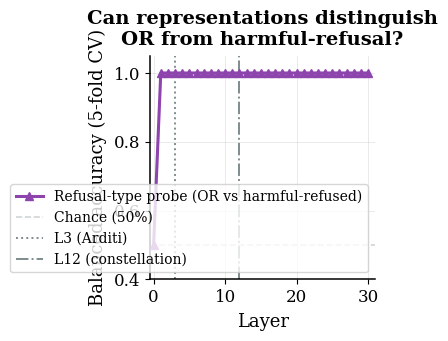

Fig 2 saved.


In [9]:
# ── Figure 2: Refusal-type probe (OR vs REFUSED_HARMFUL) ──────────────────────
# Can representations distinguish *why* a refusal occurred?
# If this probe is highly accurate at mid-layers, the model's internal state
# already encodes whether refusal is task-conditioned (OR) or content-driven (harmful).

fig, ax = plt.subplots(figsize=(3.5, 3.5))

ax.plot(layers, df['type_mu'], '^-', color=PAL['type'], lw=2.2, zorder=3,
        label='Refusal-type probe (OR vs harmful-refused)')
ax.fill_between(layers,
                df['type_mu'] - df['type_sd'],
                df['type_mu'] + df['type_sd'],
                color=PAL['type'], alpha=0.12)

ax.axhline(0.5, color=PAL['chance'], lw=1.2, ls='--', label='Chance (50%)', alpha=0.7)
ax.axvline(ARDITI_LAYER, color=PAL['ref_line'], lw=1.4, ls=':',
           label=f'L{ARDITI_LAYER} (Arditi)')
ax.axvline(CONST_PEAK,   color=PAL['ref_line'], lw=1.4, ls='-.',
           label=f'L{CONST_PEAK} (constellation)')

ax.set_xlabel('Layer', labelpad=5)
ax.set_ylabel('Balanced accuracy (5-fold CV)', labelpad=5)
ax.set_title('Can representations distinguish\nOR from harmful-refusal?', pad=8)
ax.set_xlim(-0.5, 31)
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout(pad=0.8)
plt.savefig('fig_nb17_probe_type.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb17_probe_type.png', bbox_inches='tight', dpi=300)
plt.show()
print('Fig 2 saved.')

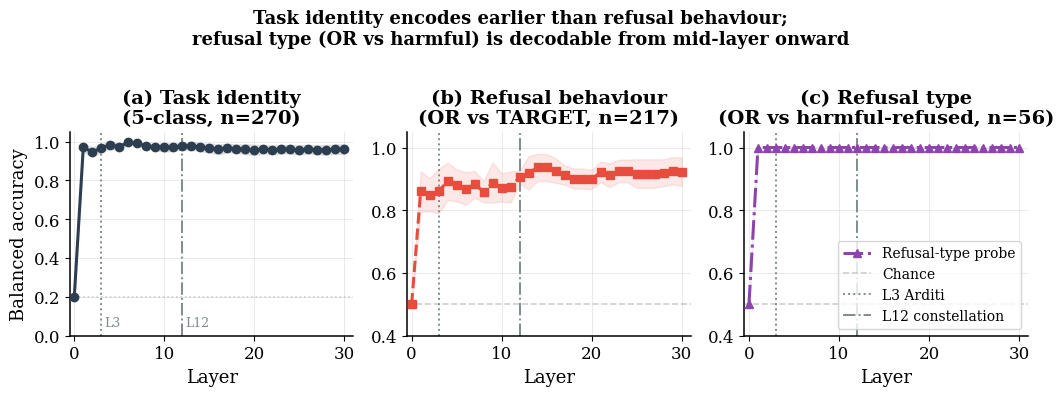

Fig 3 saved.


In [10]:
# ── Figure 3: All three probes — combined 3-panel (paper version) ─────────────
# Full-width ACL figure (figure*): figsize=(7, 3.8), 3 panels side by side.

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8), sharey=False)

# Panel A — Task probe
ax = axes[0]
ax.plot(layers, df['task_mu'], 'o-', color=PAL['task'], lw=2.2, zorder=3,
        label='Task probe')
ax.fill_between(layers, df['task_mu']-df['task_sd'], df['task_mu']+df['task_sd'],
                color=PAL['task'], alpha=0.12)
ax.axhline(1/5, color=PAL['chance'], lw=1.2, ls=':', alpha=0.8)
ax.axvline(ARDITI_LAYER, color=PAL['ref_line'], lw=1.4, ls=':')
ax.axvline(CONST_PEAK,   color=PAL['ref_line'], lw=1.4, ls='-.')
ax.set_title('(a) Task identity\n(5-class, n=270)', pad=6)
ax.set_xlabel('Layer')
ax.set_ylabel('Balanced accuracy')
ax.set_xlim(-0.5, 31); ax.set_ylim(0.0, 1.05)
ax.text(ARDITI_LAYER+0.3, 0.05, f'L{ARDITI_LAYER}', fontsize=9, color=PAL['ref_line'])
ax.text(CONST_PEAK+0.3,   0.05, f'L{CONST_PEAK}',   fontsize=9, color=PAL['ref_line'])

# Panel B — Refusal-behaviour probe
ax = axes[1]
n_b = BEHAV_MASK.sum()
ax.plot(layers, df['behav_mu'], 's--', color=PAL['refusal'], lw=2.2, zorder=3,
        label='Refusal-behav probe')
ax.fill_between(layers, df['behav_mu']-df['behav_sd'], df['behav_mu']+df['behav_sd'],
                color=PAL['refusal'], alpha=0.12)
ax.axhline(0.5, color=PAL['chance'], lw=1.2, ls='--', alpha=0.8)
ax.axvline(ARDITI_LAYER, color=PAL['ref_line'], lw=1.4, ls=':')
ax.axvline(CONST_PEAK,   color=PAL['ref_line'], lw=1.4, ls='-.')
ax.set_title(f'(b) Refusal behaviour\n(OR vs TARGET, n={n_b})', pad=6)
ax.set_xlabel('Layer')
ax.set_xlim(-0.5, 31); ax.set_ylim(0.4, 1.05)

# Panel C — Refusal-type probe
ax = axes[2]
n_t = TYPE_MASK.sum()
ax.plot(layers, df['type_mu'], '^-.', color=PAL['type'], lw=2.2, zorder=3,
        label='Refusal-type probe')
ax.fill_between(layers, df['type_mu']-df['type_sd'], df['type_mu']+df['type_sd'],
                color=PAL['type'], alpha=0.12)
ax.axhline(0.5, color=PAL['chance'], lw=1.2, ls='--', alpha=0.8, label='Chance')
ax.axvline(ARDITI_LAYER, color=PAL['ref_line'], lw=1.4, ls=':',  label=f'L{ARDITI_LAYER} Arditi')
ax.axvline(CONST_PEAK,   color=PAL['ref_line'], lw=1.4, ls='-.', label=f'L{CONST_PEAK} constellation')
ax.set_title(f'(c) Refusal type\n(OR vs harmful-refused, n={n_t})', pad=6)
ax.set_xlabel('Layer')
ax.set_xlim(-0.5, 31); ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=10, loc='lower right')

plt.suptitle('Task identity encodes earlier than refusal behaviour;\n'
             'refusal type (OR vs harmful) is decodable from mid-layer onward',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(pad=0.8)
plt.savefig('fig_nb17_probe_all3.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_nb17_probe_all3.png', bbox_inches='tight', dpi=300)
plt.show()
print('Fig 3 saved.')

In [13]:
# ── Find the crossover / peak layers ──────────────────────────────────────────
# Identify the layer at which each probe first exceeds a threshold,
# and the layer at which it peaks.

THRESHOLD = 0.70   # "informative" threshold

def first_above(series, threshold):
    idx = np.where(series.values >= threshold)[0]
    return layers[idx[0]] if len(idx) > 0 else None

def peak_layer(series):
    return layers[series.values.argmax()]

print('=== PROBE SUMMARY ===')
print()
for col, name, chance in [
    ('task_mu',  'Task probe  (5-class)',          0.20),
    ('behav_mu', 'Refusal-behav (OR vs TARGET)',    0.50),
    ('type_mu',  'Refusal-type (OR vs harmful)',    0.50),
]:
    peak  = peak_layer(df[col])
    first = first_above(df[col], THRESHOLD)
    maxv  = df[col].max()
    print(f'{name}')
    print(f'  Chance={chance:.0%}  |  Peak acc={maxv:.3f} at L{peak}  |  '
          f'First >{THRESHOLD:.0%} at L{first}')
    print()

task_first  = first_above(df['task_mu'],  THRESHOLD)
behav_first = first_above(df['behav_mu'], THRESHOLD)
gap = (behav_first or 99) - (task_first or 99)
print(f'── Temporal gap (refusal-behav first>{THRESHOLD:.0%} minus task first>{THRESHOLD:.0%}): {gap} layers')
print()
print('─── §4.x sentence to copy ───')
print(f'  "A linear probe decodes task identity above {THRESHOLD:.0%} balanced accuracy from '
      f'L{task_first} onward (peak {df["task_mu"].max():.2f}), whereas a probe for '
      f'refusal behaviour (OR vs TARGET) does not exceed {THRESHOLD:.0%} until '
      f'L{behav_first} — a gap of {gap} layers consistent with the timeline in '
      f'which task constellations form (L{CONST_PEAK}) before refusal is committed '
      f'(L27--L31 attention heads, NB12)."')

=== PROBE SUMMARY ===

Task probe  (5-class)
  Chance=20%  |  Peak acc=0.996 at L6  |  First >70% at L1

Refusal-behav (OR vs TARGET)
  Chance=50%  |  Peak acc=0.936 at L14  |  First >70% at L1

Refusal-type (OR vs harmful)
  Chance=50%  |  Peak acc=1.000 at L1  |  First >70% at L1

── Temporal gap (refusal-behav first>70% minus task first>70%): 0 layers

─── §4.x sentence to copy ───
  "A linear probe decodes task identity above 70% balanced accuracy from L1 onward (peak 1.00), whereas a probe for refusal behaviour (OR vs TARGET) does not exceed 70% until L1 — a gap of 0 layers consistent with the timeline in which task constellations form (L12) before refusal is committed (L27--L31 attention heads, NB12)."
